1. Imports

In [8]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

2. Load Data and Model

In [9]:
df = pd.read_csv("../data/processed/features.csv")
df["date"] = pd.to_datetime(df["date"])

model = joblib.load("../models/best_model.pkl")

print("Data shape:", df.shape)
print("Model loaded:", type(model).__name__)

Data shape: (1654, 14)
Model loaded: XGBRegressor


3. Time-Based Split and Predictions

In [10]:
FEATURES = [c for c in df.columns if c not in ["date", "sales"]]

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:].copy()

X_test = test[FEATURES]
y_test = test["sales"]

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Test MAE:  {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Test MAE:  69480.42
Test RMSE: 109974.27


4. Plot Actual vs Predicted

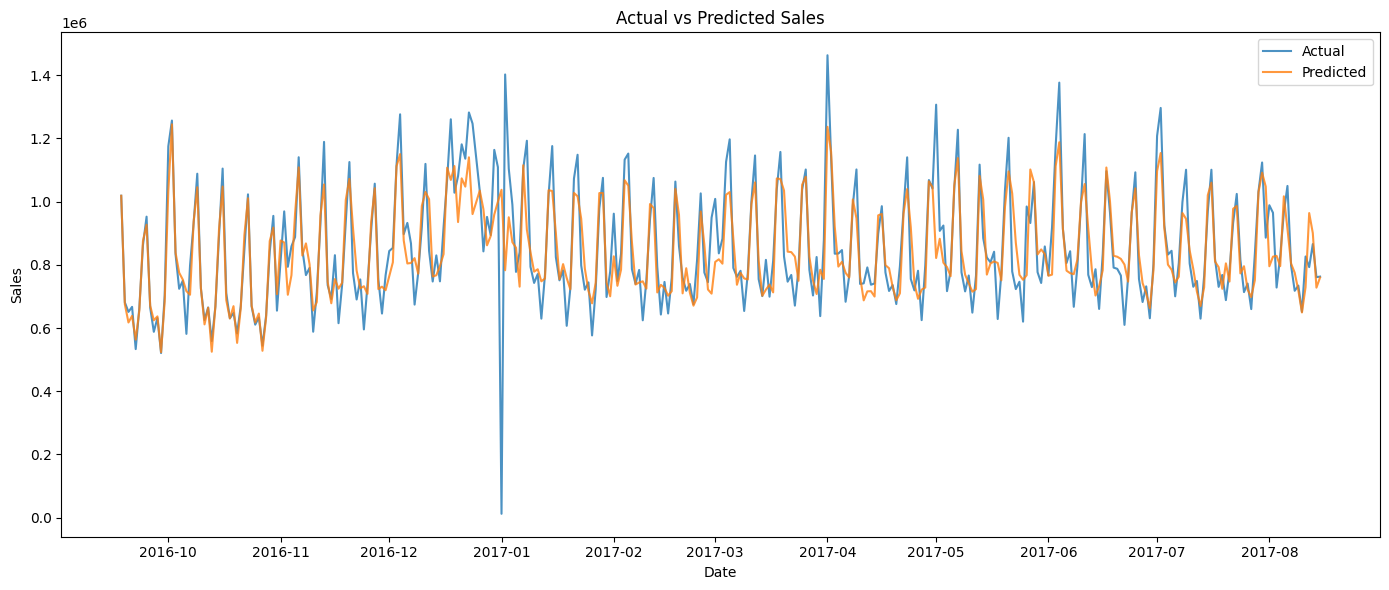

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(test["date"].values, y_test.values, label="Actual", alpha=0.8)
plt.plot(test["date"].values, predictions, label="Predicted", alpha=0.8)
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

5. Recursive Multi-Step Forecasting (30 Days)

In [12]:
history = df["sales"].values.tolist()
last_date = df["date"].max()

forecast_dates = []
forecast_values = []

for i in range(30):
    next_date = last_date + pd.Timedelta(days=i + 1)

    year = next_date.year
    month = next_date.month
    day = next_date.day
    dayofweek = next_date.dayofweek
    weekofyear = next_date.isocalendar()[1]
    is_weekend = 1 if dayofweek in [5, 6] else 0

    lag_1 = history[-1]
    lag_7 = history[-7] if len(history) >= 7 else history[-1]
    lag_30 = history[-30] if len(history) >= 30 else history[-1]

    rolling_7_mean = np.mean(history[-7:])
    rolling_30_mean = np.mean(history[-30:])
    rolling_7_std = np.std(history[-7:], ddof=1) if len(history) >= 7 else 0.0

    row = pd.DataFrame([{
        "year": year,
        "month": month,
        "day": day,
        "dayofweek": dayofweek,
        "weekofyear": weekofyear,
        "is_weekend": is_weekend,
        "lag_1": lag_1,
        "lag_7": lag_7,
        "lag_30": lag_30,
        "rolling_7_mean": rolling_7_mean,
        "rolling_30_mean": rolling_30_mean,
        "rolling_7_std": rolling_7_std,
    }])

    pred = model.predict(row[FEATURES])[0]

    forecast_dates.append(next_date)
    forecast_values.append(pred)
    history.append(pred)  # feed prediction back as history

forecast_df = pd.DataFrame({"date": forecast_dates, "forecasted_sales": forecast_values})
print(forecast_df)

         date  forecasted_sales
0  2017-08-16       785213.6875
1  2017-08-17       721193.7500
2  2017-08-18       721731.6875
3  2017-08-19       937521.0000
4  2017-08-20       927557.8750
5  2017-08-21       801659.0625
6  2017-08-22       791165.8125
7  2017-08-23       788797.1875
8  2017-08-24       773475.5000
9  2017-08-25       791974.5625
10 2017-08-26       929018.3125
11 2017-08-27       929720.9375
12 2017-08-28       783984.6250
13 2017-08-29       790642.6250
14 2017-08-30       816751.9375
15 2017-08-31       791618.6250
16 2017-09-01       595747.8125
17 2017-09-02       953888.1250
18 2017-09-03       924498.8125
19 2017-09-04       782244.6250
20 2017-09-05       731454.0625
21 2017-09-06       726817.5625
22 2017-09-07       654572.7500
23 2017-09-08       641194.8125
24 2017-09-09       892044.5625
25 2017-09-10       926567.2500
26 2017-09-11       696461.0000
27 2017-09-12       645188.3125
28 2017-09-13       672447.8750
29 2017-09-14       602320.3125


6. Save Forecast

In [13]:
os.makedirs("../outputs/forecasts", exist_ok=True)

forecast_df.to_csv("../outputs/forecasts/next_30_days.csv", index=False)
print("Saved forecast to outputs/forecasts/next_30_days.csv")

Saved forecast to outputs/forecasts/next_30_days.csv


7. Plot and Save Forecast

Saved forecast plot to outputs/figures/forecast_plot.png


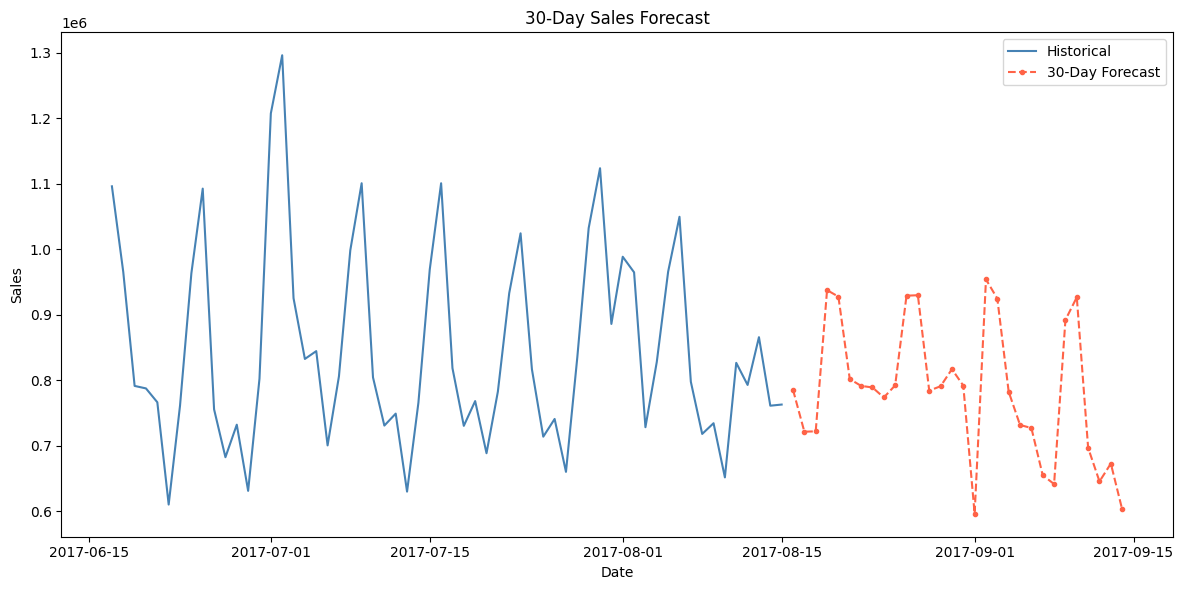

In [14]:
os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(12, 6))

recent = df.tail(60)
plt.plot(recent["date"].values, recent["sales"].values, label="Historical", color="steelblue")

plt.plot(forecast_df["date"].values, forecast_df["forecasted_sales"].values,
         label="30-Day Forecast", color="tomato", linestyle="--", marker="o", markersize=3)

plt.legend()
plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../outputs/figures/forecast_plot.png", dpi=150)
print("Saved forecast plot to outputs/figures/forecast_plot.png")
plt.show()

## 📌 Summary

- Loaded processed features and trained model
- Generated and evaluated predictions on test set (MAE, RMSE)
- Plotted Actual vs Predicted sales
- Implemented recursive multi-step forecasting for 30 days
- Saved forecast CSV to `outputs/forecasts/next_30_days.csv`
- Saved forecast plot to `outputs/figures/forecast_plot.png`

### 🎯 Purpose
Deliver actionable business predictions and visualizations for stakeholder review.